В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [215]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [7]:
df_cars = pd.read_csv('cars.csv')
df_cars.head(5)

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [11]:
df_cars.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [15]:
df_cars.select_dtypes(include='object').nunique()

Brand           11
Model           58
Fuel_Type        2
Transmission     2
Owner_Type       3
dtype: int64

В наборі даних 8 числових (з них одна індекс, яку теж можна вважати категоріальною) і 5 категоріальних колонок з них
- 2 бінарні 
- 2 мультикатегоріальних зі значеннями, для яких немає відношення порядку
- 1 колонка, в якій можна встановити відношення порядку 

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [108]:
X = df_cars.drop(columns=["Price"]) 
y = df_cars["Price"]                 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [110]:
inputs_train.shape, inputs_test.shape
X_train

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5
...,...,...,...,...,...,...,...,...,...,...,...,...
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4
6,7,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,140,7
27,28,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,187,5


In [151]:
df_cars["Price"].describe()

count    1.000000e+02
mean     1.574000e+06
std      1.000265e+06
min      4.500000e+05
25%      7.000000e+05
50%      1.300000e+06
75%      2.500000e+06
max      4.000000e+06
Name: Price, dtype: float64

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [112]:
df_cars["Transmission"].value_counts()

Transmission
Automatic    57
Manual       43
Name: count, dtype: int64

In [114]:
Fuel_map = {'Diesel': 0, 'Petrol': 1}
X_train['Fuel_isPetrol'] = X_train.Fuel_Type.map(Fuel_map)
X_test['Fuel_isPetrol'] = X_test.Fuel_Type.map(Fuel_map)

Transmission_map = {'Manual': 0, 'Automatic': 1}
X_train['Transmission_isAutomatic'] = X_train.Transmission.map(Transmission_map)
X_test['Transmission_isAutomatic'] = X_test.Transmission.map(Transmission_map)

#X_train.head(5), X_test.head(5)

In [116]:
enc = preprocessing.OneHotEncoder()
enc.fit(X_train[['Brand']])
enc.categories_
#enc.categories_[0]

X_train[enc.categories_[0]] = enc.transform(X_train[['Brand']]).toarray()
X_test[enc.categories_[0]] = enc.transform(X_test[['Brand']]).toarray()


In [118]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

In [120]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_isPetrol,Transmission_isAutomatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_isPetrol,Transmission_isAutomatic,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

Очікуваний результат після трансформацій:

In [ ]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

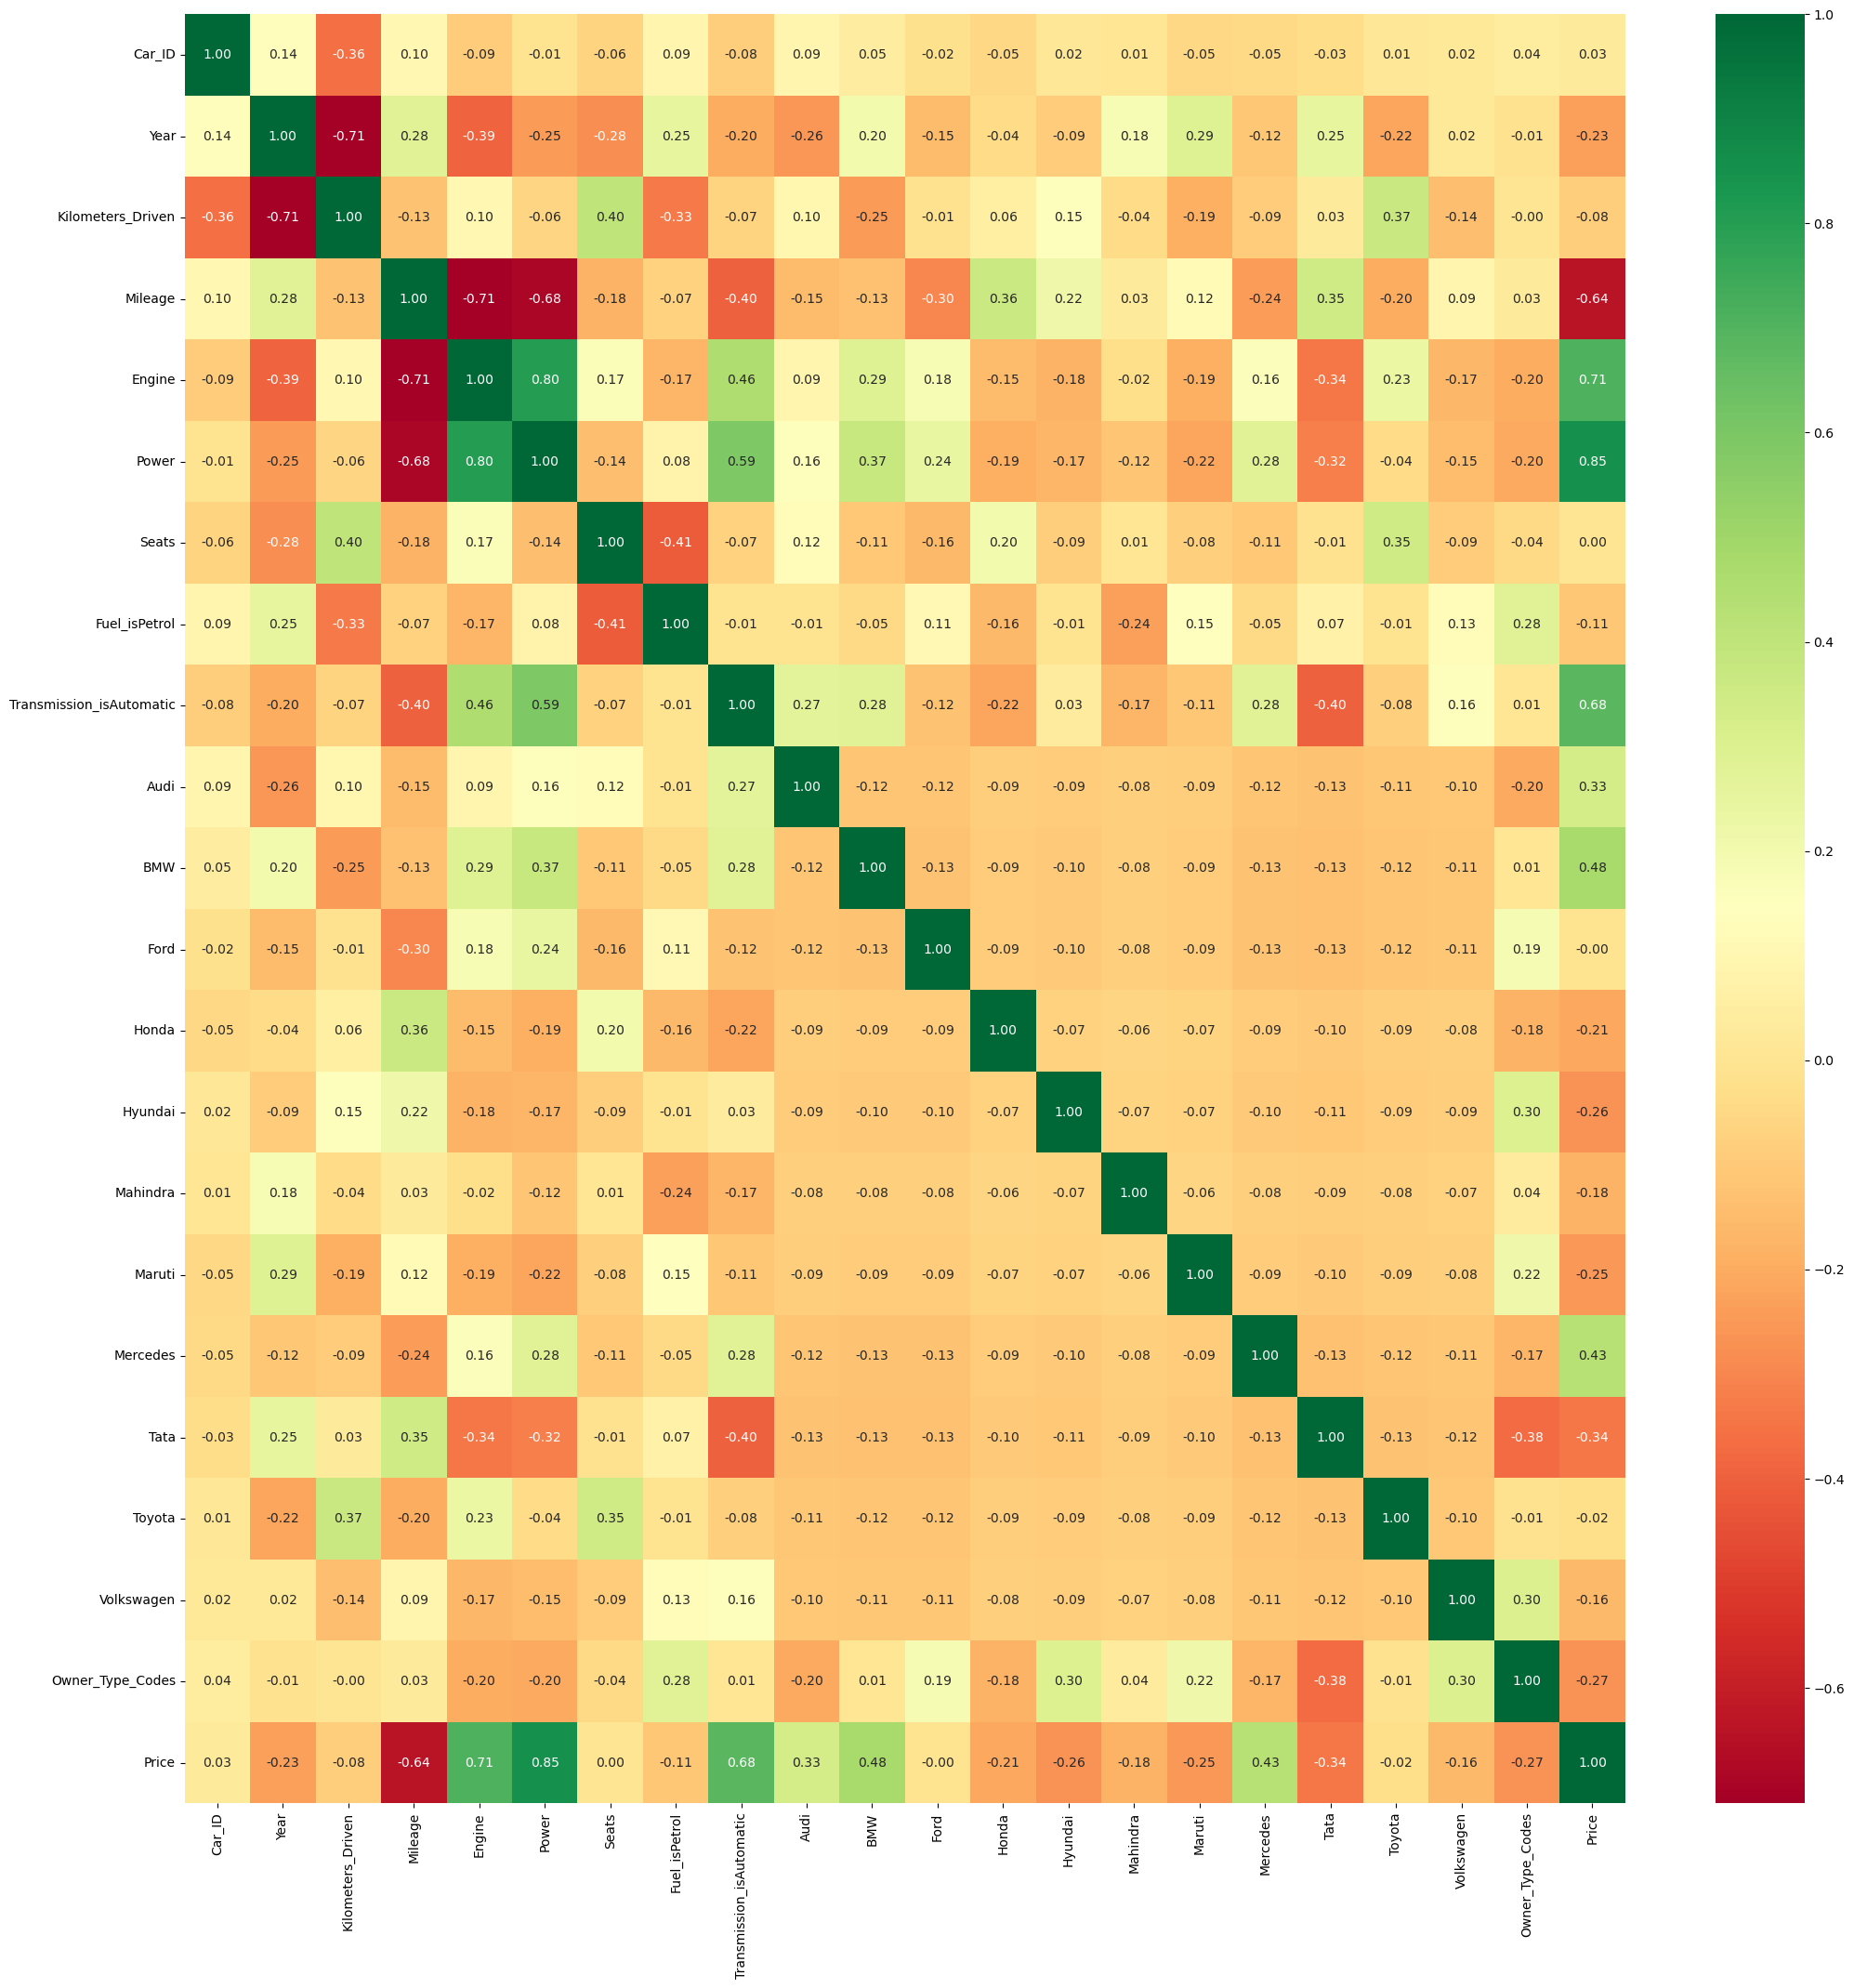

In [122]:
X_train = X_train.select_dtypes(include=['number'])
num_df = pd.concat([X_train, y_train], axis=1)
corr_matrix = num_df.corr()
plt.figure(figsize = (25,25))
sns.heatmap(corr_matrix, annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

Колонки які корелюють з цільовою змінною більше ніж на 0.5: 
- Mileage
- Engine
- Power
- Transmission_isAutomatic

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [131]:
X_test = X_test.select_dtypes(include=['number'])

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

predictions_sklearn_train = lin_reg.predict(X_train)
predictions_sklearn_test = lin_reg.predict(X_test)
rmse_sklearn_train = mean_squared_error(y_train, predictions_sklearn_train, squared=False)
rmse_sklearn_test = mean_squared_error(y_test, predictions_sklearn_test, squared=False)
rmse_sklearn_train, rmse_sklearn_test

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(210293.5782815184, 258181.56112032846)

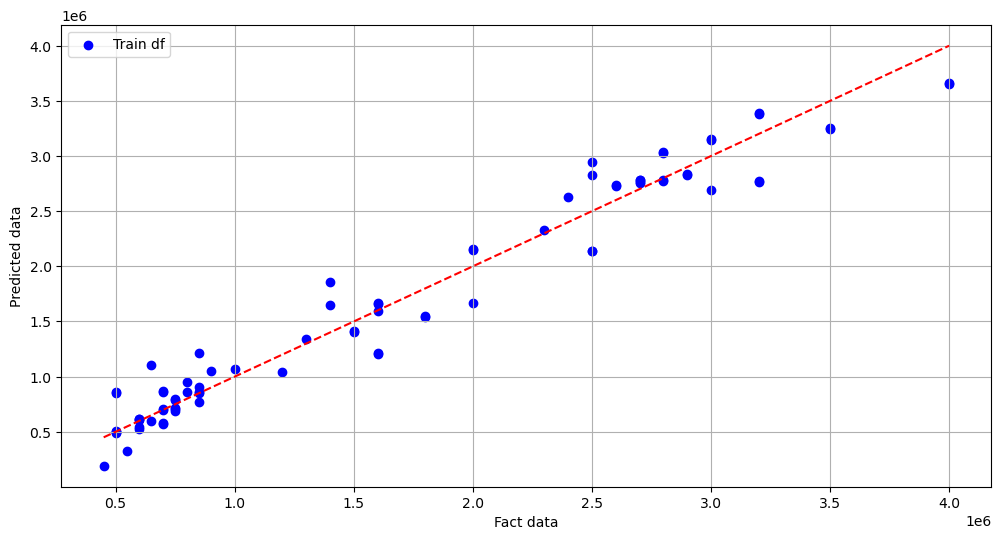

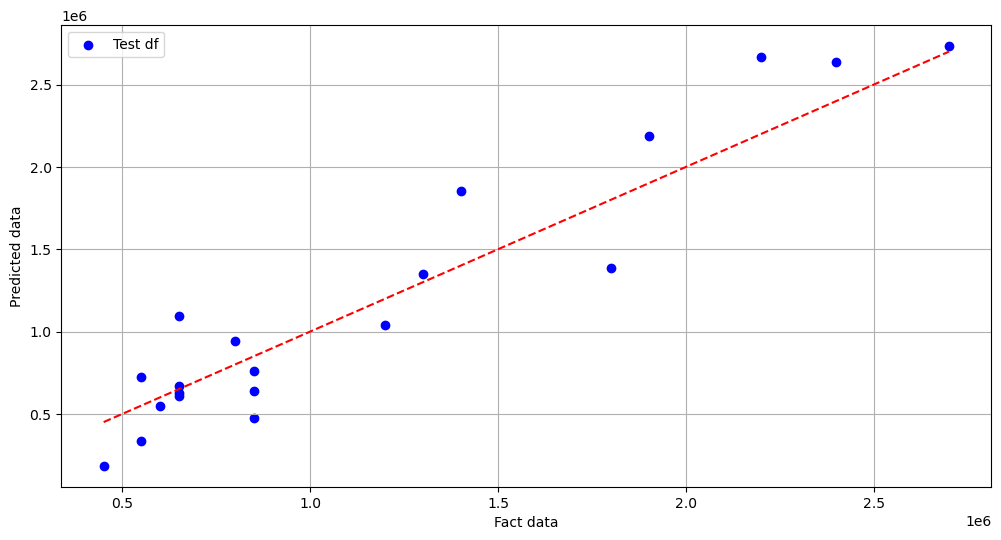

In [155]:
plt.figure(figsize=(12, 6))
plt.scatter(y_train, predictions_sklearn_train, color='blue', label='Train df')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.xlabel('Fact data')
plt.ylabel('Predicted data')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(y_test, predictions_sklearn_test, color='blue', label='Test df')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Fact data')
plt.ylabel('Predicted data')
plt.legend()
plt.grid(True)
plt.show()

Модель передбачає тестові дані гірше ніж тренувальні, але RMSE навіть для тестових даних досить непогане відносно стандартного відхилення цільової змінної

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [200]:
numeric_cols = ['Year', 'Kilometers_Driven', 'Mileage','Engine', 'Power', 'Seats']
scaler = StandardScaler()
scaler.fit(X_train[numeric_cols]) 

scaled_inputs_train = scaler.transform(X_train[numeric_cols])
scaled_inputs_test = scaler.transform(X_test[numeric_cols])

cat_cols = ['Fuel_isPetrol', 'Transmission_isAutomatic', 'Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti', 'Mercedes', 'Tata', 'Toyota', 'Volkswagen', 'Owner_Type_Codes']
X_scaled_train = np.concatenate((scaled_inputs_train, X_train[cat_cols].values), axis=1)
X_scaled_test = np.concatenate((scaled_inputs_test, X_test[cat_cols].values), axis=1)

In [213]:
lin_reg_scaled = LinearRegression()

lin_reg_scaled.fit(X_scaled_train, y_train)

predictions_scaled_train = lin_reg_scaled.predict(X_scaled_train)
predictions_scaled_test = lin_reg_scaled.predict(X_scaled_test)

weights_df = pd.DataFrame({
     'feature': np.append(numeric_cols + cat_cols, 1),
     'weight': np.append(lin_reg_scaled.coef_, lin_reg_scaled.intercept_)
 })
weights_df.sort_values('weight', ascending=False)

,feature,weight
20,1,1.604276e+06
8,Audi,7.588030e+05
15,Mercedes,7.339747e+05
9,BMW,7.303268e+05
4,Power,5.000005e+05
7,Transmission_isAutomatic,2.363676e+05
17,Toyota,1.304575e+05
19,Owner_Type_Codes,6.627831e+04
5,Seats,-1.744049e+03
0,Year,-1.160426e+04


Судячи з коєфіцієнтів найбільше впливає на ціну марка машини, дорога марка підвищує ціну, дешеві знижають. Також чим більше пробіг тим нижче ціна, що теж логічно. Також ми маємо базову ціну машини, це зсув лінійної моделі

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [225]:
Y = y_train
column_names = numeric_cols + cat_cols
X = pd.DataFrame(X_scaled_train, columns=column_names, index=Y.index)
X = sm.add_constant(X)
model = sm.OLS(Y,X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     73.14
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           2.34e-34
Time:                        01:33:15   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      60   BIC:                             2276.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                     1.471e+06   7.09e+04     20.756      0.000    1.33e+06    1.61e+06
Year                      -1.16e+04    5.8e+04     -0.200      0.842   -1.28e+05    1.04e+05
Kilometers_Driven        -9.971e+04   5.63e+04     -1.772      0.082   -2.12e+05    1.29e+04
Mileage                  -1.319e+05   5.78e+04     -2.281      0.026   -2.48e+05   -1.62e+04
Engine                   -2.468e+04   6.95e+04     -0.355      0.724   -1.64e+05    1.14e+05
Power                         5e+05   7.23e+04      6.919      0.000    3.55e+05    6.45e+05
Seats                    -1744.0488   4.18e+04     -0.042      0.967   -8.53e+04    8.18e+04
Fuel_isPetrol            -3.706e+05   8.91e+04     -4.161      0.000   -5.49e+05   -1.92e+05
Transmission_isAutomatic  2.364e+05   8.75e+04      2.700      0.009    6.13e+04    4.11e+05
Audi                      8.925e+05   1.04e+05      8.587      0.000    6.85e+05     1.1e+06
BMW                        8.64e+05   1.03e+05      8.415      0.000    6.59e+05    1.07e+06
Ford                     -1.714e+05   1.06e+05     -1.610      0.113   -3.84e+05    4.16e+04
Honda                    -5.531e+04   1.37e+05     -0.405      0.687   -3.29e+05    2.18e+05
Hyundai                  -3.714e+05   1.09e+05     -3.419      0.001   -5.89e+05   -1.54e+05
Mahindra                 -4.412e+05   1.29e+05     -3.422      0.001   -6.99e+05   -1.83e+05
Maruti                   -2.605e+05   1.16e+05     -2.248      0.028   -4.92e+05   -2.87e+04
Mercedes                  8.677e+05   1.01e+05      8.563      0.000    6.65e+05    1.07e+06
Tata                      7185.4630   1.17e+05      0.061      0.951   -2.28e+05    2.42e+05
Toyota                    2.641e+05    1.1e+05      2.401      0.019    4.41e+04    4.84e+05
Volkswagen               -1.251e+05   1.07e+05     -1.168      0.248   -3.39e+05    8.92e+04
Owner_Type_Codes          6.628e+04   7.15e+04      0.927      0.357   -7.67e+04    2.09e+05
==============================================================================
Omnibus:                        0.150   Durbin-Watson:                   2.054
Prob(Omnibus):                  0.928   Jarque-Bera (JB):                0.272
Skew:                           0.093   Prob(JB):                        0.873
Kurtosis:                       2.784   Cond. No.                     2.20e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.75e-31. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

Стат значущими є такі ознаки: Power, Fuel_isPetrol, Audi, BMW, Hyundai, Mahindra, Mercedes

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [231]:
imp_cols = ["Power", "Fuel_isPetrol", "Audi", "BMW", "Hyundai", "Mahindra", "Mercedes"]

X_005 = X[imp_cols]
X_005 = sm.add_constant(X_005)
model_005 = sm.OLS(Y,X_005)
results_005 = model_005.fit()
results_005.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     141.3
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           1.94e-39
Time:                        01:48:52   Log-Likelihood:                -1113.8
No. Observations:                  80   AIC:                             2244.
Df Residuals:                      72   BIC:                             2263.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.528e+06   6.06e+04     25.208      0.000    1.41e+06    1.65e+06
Power          6.022e+05   3.87e+04     15.541      0.000    5.25e+05    6.79e+05
Fuel_isPetrol -2.882e+05   6.65e+04     -4.335      0.000   -4.21e+05   -1.56e+05
Audi           1.032e+06   1.14e+05      9.063      0.000    8.05e+05    1.26e+06
BMW            1.036e+06   1.18e+05      8.795      0.000    8.01e+05    1.27e+06
Hyundai       -2.978e+05   1.24e+05     -2.400      0.019   -5.45e+05   -5.05e+04
Mahindra      -3.436e+05   1.53e+05     -2.242      0.028   -6.49e+05    -3.8e+04
Mercedes       1.058e+06   1.14e+05      9.321      0.000    8.32e+05    1.28e+06
==============================================================================
Omnibus:                       22.377   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.673
Skew:                           1.208   Prob(JB):                     1.33e-07
Kurtosis:                       4.914   Cond. No.                         6.28
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R2 трохи зменшилось, але розрив між R2 і Adj. R-squared став менше тому що стало меньше ознак які не впливають на результат

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 7 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 7? Яку модель з останніх 3х завдань ви б лишили для використання?

In [237]:
imp25_cols = ["Power", "Fuel_isPetrol", "Audi", "BMW", "Hyundai", "Mahindra", "Mercedes", "Toyota", "Transmission_isAutomatic"]

X_025 = X[imp25_cols]
X_025 = sm.add_constant(X_025)
model_025 = sm.OLS(Y,X_025)
results_025 = model_025.fit()
results_025.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     147.4
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           7.22e-42
Time:                        01:55:28   Log-Likelihood:                -1101.7
No. Observations:                  80   AIC:                             2223.
Df Residuals:                      70   BIC:                             2247.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                     1.325e+06   6.83e+04     19.413      0.000    1.19e+06    1.46e+06
Power                     5.364e+05   3.76e+04     14.256      0.000    4.61e+05    6.11e+05
Fuel_isPetrol            -2.642e+05   5.81e+04     -4.544      0.000    -3.8e+05   -1.48e+05
Audi                      1.002e+06   1.07e+05      9.392      0.000    7.89e+05    1.21e+06
BMW                       1.045e+06   1.08e+05      9.691      0.000     8.3e+05    1.26e+06
Hyundai                  -3.142e+05   1.12e+05     -2.799      0.007   -5.38e+05   -9.03e+04
Mahindra                 -2.373e+05   1.35e+05     -1.752      0.084   -5.07e+05    3.28e+04
Mercedes                   1.05e+06   1.05e+05      9.989      0.000     8.4e+05    1.26e+06
Toyota                    3.522e+05   9.75e+04      3.612      0.001    1.58e+05    5.47e+05
Transmission_isAutomatic  2.524e+05   7.72e+04      3.269      0.002    9.84e+04    4.06e+05
==============================================================================
Omnibus:                        2.573   Durbin-Watson:                   1.872
Prob(Omnibus):                  0.276   Jarque-Bera (JB):                2.526
Skew:                           0.417   Prob(JB):                        0.283
Kurtosis:                       2.751   Cond. No.                         8.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Для мене найоптімальніша остання модель, в неї вище R2 ніж в другої, але меньше розрив між R2 і Adj. R-squared ніж в першої. Виглядає, ніби вона враховує всі найважливіші ознаки.